## **MCF7 - Smart Sequence - Supervised Learning**

### **Introduction**

<p style="font-size:15px; line-height:1.6;">Now, we proceed with the implementation of supervised learning methods to better understand the behavior of gene expression data across different sequencing technologies and cell lines. The goal is to develop models that not only achieve good predictive performance, but also provide insightful biological information of the underlying patterns in the data. </p>

<p style="font-size:15px; line-height:1.6;">For all of our datasets, we implement several supervised learning algorithms, including Logistic Regression, Random Forests,  K-Nearest Neighbors (kNN), Support Vector Machine (SVM) and finally, an ensemble model. </p>

<p style="font-size:15px; line-height:1.6;"> These models are selected because of their complementary strengths. <b>Logistic Regression</b>, although the simplest model, offers high interpretability and allows us to identify the genes that contribute most to the classification task. <b>Random Forests</b> reduce the risk of overfitting and are able to capture nonlinear relationships between features. <b>SVMs</b> are particularly suitable for high-dimensional datasets such as gene expression data, whereas <b>KNN</b> can effectively capture local similarities between samples and complex decision boundaries in the data. By combining the strengths of multiple models, <b>ensemble</b> learning can improve predictive performance and reduce the risk of relying on a single model. To further improve model performance, we perform hyperparameter tuning for each classifier. </p>


In this notebook, we focus primarily on the <b>MCF7 SmartSeq dataset</b>.

<p style="font-size:15px; line-height:1.6;"> At the end, we evaluate the models trained on this dataset across all cell lines and sequencing technologies. Using the best-performing model across both cell lines and sequencing technologies, we investigate the biological pathways associated with the most important genes. This analysis is presented in the supervised learning notebook corresponding to the dataset on which the selected model was originally trained. </p>

**Our Models are:**
* Logistic Regression

* Random Forests

* K-Nearest Neighbors (kNN)
* Support Vector Machine (SVM)
* Ensemble method

##### **Structure of the file**

1. **Supervised Learning**

    - Test/Train Split

    - Training and Evaluating Models

    - Best Learning Model on MCF7 SmartSeq

    - Best Model across cell lines and experiments

2. **Predictions (Testing on Unseen Data)**


##### **Libraries**

In [578]:
import sys
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc



### **Supervised Learning**

<p style="font-size:15px; line-height:1.6;">First, we import the dataset, which has been filtered, normalized and contains only the 3000 most variable genes. </p>

In [579]:
dataset = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt",sep="\ ")
dataset.head()

/var/folders/16/tfbhmgyn1v9b65ldf1_dv9r80000gn/T/ipykernel_65825/825500497.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  dataset = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt",sep="\ ")


,"""output.STAR.2_B3_Norm_S57_Aligned.sortedByCoord.out.bam""","""output.STAR.2_B4_Norm_S58_Aligned.sortedByCoord.out.bam""","""output.STAR.2_B5_Norm_S59_Aligned.sortedByCoord.out.bam""","""output.STAR.2_B6_Norm_S60_Aligned.sortedByCoord.out.bam""","""output.STAR.2_B7_Hypo_S79_Aligned.sortedByCoord.out.bam""","""output.STAR.2_B9_Hypo_S81_Aligned.sortedByCoord.out.bam""","""output.STAR.2_C10_Hypo_S130_Aligned.sortedByCoord.out.bam""","""output.STAR.2_C11_Hypo_S131_Aligned.sortedByCoord.out.bam""","""output.STAR.2_C1_Norm_S103_Aligned.sortedByCoord.out.bam""","""output.STAR.2_C2_Norm_S104_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.4_H10_Hypo_S382_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H14_Hypo_S383_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H1_Norm_S355_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H3_Norm_S357_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H4_Norm_S358_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H5_Norm_S359_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H6_Norm_S360_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H7_Hypo_S379_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H8_Hypo_S380_Aligned.sortedByCoord.out.bam""","""output.STAR.4_H9_Hypo_S381_Aligned.sortedByCoord.out.bam"""
"""CYP1B1""",343,131,452,27,5817,3841,9263,21543,1013,53,...,7890,4512,160,351,327,196,504,34565,20024,5953
"""CYP1B1-AS1""",140,59,203,7,2669,1565,3866,9113,459,22,...,3647,2035,75,138,130,102,238,13717,7835,2367
"""CYP1A1""",0,0,0,0,0,79,238,443,0,0,...,86,1654,0,0,0,1,0,11274,563,522
"""NDRG1""",0,1,0,0,654,1263,2634,540,0,13,...,481,1052,0,0,54,243,62,1263,925,1572
"""DDIT4""",386,289,0,288,2484,2596,1323,2044,36,204,...,3692,2410,800,1,189,266,417,4256,12733,2275


In [580]:
dataset.shape

(3000, 250)

##### **Dataset Cleaning**

<p style="font-size:15px; line-height:1.6;">As a first step, we define a function responsible for removing unnecessary double quotation marks from row and column names. Defining this step inside a dedicated function allows the preprocessing pipeline to be reused consistently across all models and datasets. We follow the same method for further functions that need to be used throughout the modelling. We also transpose the matrix, so that it's format is ready for supervised learning.</p>

In [581]:
def remove_double_quotes(word):
    return word.replace('"', '')
dataset = dataset.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in dataset.T.columns})
dataset = dataset.T
dataset = dataset.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in dataset.columns})

In [582]:
dataset.head()

,CYP1B1,CYP1B1-AS1,CYP1A1,NDRG1,DDIT4,PFKFB3,HK2,AREG,MYBL2,ADM,...,CD27-AS1,DNAI7,MAFG,LZTR1,BCO2,GRIK5,SLC25A27,DENND5A,CDK5R1,FAM13A-AS1
"""output.STAR.2_B3_Norm_S57_Aligned.sortedByCoord.out.bam""",343,140,0,0,386,75,0,0,476,0,...,63,0,17,59,0,0,0,51,0,0
"""output.STAR.2_B4_Norm_S58_Aligned.sortedByCoord.out.bam""",131,59,0,1,289,42,0,856,1586,0,...,0,0,1,25,0,0,0,34,0,0
"""output.STAR.2_B5_Norm_S59_Aligned.sortedByCoord.out.bam""",452,203,0,0,0,0,0,0,775,0,...,15,0,23,0,0,0,0,0,0,0
"""output.STAR.2_B6_Norm_S60_Aligned.sortedByCoord.out.bam""",27,7,0,0,288,214,15,242,1191,0,...,1,0,3,10,0,0,0,4,0,0
"""output.STAR.2_B7_Hypo_S79_Aligned.sortedByCoord.out.bam""",5817,2669,0,654,2484,1603,748,436,0,0,...,0,0,63,0,0,0,0,60,0,0


We check one more time that the dataset is balanced:

In [583]:
dataset['label'] = dataset.index.to_series().apply(lambda x: 'Normoxia' if 'Norm' in x else 'Hypoxia')
dataset["label"].value_counts() 

label
Normoxia    126
Hypoxia     124
Name: count, dtype: int64

##### **Preparation**

<p style="font-size:15px; line-height:1.6;"> We define the function that constructs the feature matrix X and the target vector y. The gene expression values are used as input features, while each cell is assigned a label according to its biological condition (Normoxia or Hypoxia).</p>

<p style="font-size:15px; line-height:1.6;"> We also define a function that splits the dataset into training (80%) and testing subsets (20%), using a stratified split.  </p>

In [584]:
# Create the labels 
dataset['label'] = dataset.index.to_series().apply(lambda x: 0 if 'Norm' in x else 1)

# Define the feature matrix X 
X = dataset.drop("label", axis = 1)
# And the target vector y 
y = dataset["label"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.2, stratify=y, random_state=123)
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)
X_train

(200, 3000) (200,) (50, 3000) (50,)


,CYP1B1,CYP1B1-AS1,CYP1A1,NDRG1,DDIT4,PFKFB3,HK2,AREG,MYBL2,ADM,...,CD27-AS1,DNAI7,MAFG,LZTR1,BCO2,GRIK5,SLC25A27,DENND5A,CDK5R1,FAM13A-AS1
"""output.STAR.3_D2_Norm_S158_Aligned.sortedByCoord.out.bam""",660,278,0,0,1390,168,0,19,1833,0,...,1,0,36,3,0,0,0,19,0,0
"""output.STAR.4_B6_Norm_S72_Aligned.sortedByCoord.out.bam""",1522,596,0,13,8,12,22,27,1164,7,...,37,0,37,22,0,0,0,32,0,0
"""output.STAR.3_D7_Hypo_S181_Aligned.sortedByCoord.out.bam""",3530,1473,0,817,3011,1962,686,1000,26,21,...,0,0,38,41,0,14,0,89,0,0
"""output.STAR.2_E11_Hypo_S227_Aligned.sortedByCoord.out.bam""",2600,1064,0,642,3038,1647,470,1076,0,0,...,30,0,22,1,0,0,0,55,0,1
"""output.STAR.4_D5_Norm_S167_Aligned.sortedByCoord.out.bam""",101,40,0,0,7,189,13,206,742,0,...,5,0,11,2,0,0,0,18,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"""output.STAR.3_B3_Norm_S63_Aligned.sortedByCoord.out.bam""",52,29,0,2,112,39,0,62,3108,0,...,0,0,3,0,0,0,0,0,0,0
"""output.STAR.4_F11_Hypo_S287_Aligned.sortedByCoord.out.bam""",21022,9345,6028,1129,1284,284,505,13,0,42,...,146,5,0,0,0,0,0,26,0,33
"""output.STAR.3_B2_Norm_S62_Aligned.sortedByCoord.out.bam""",386,155,0,0,24,24,0,0,1559,9,...,75,0,45,101,0,0,0,67,0,0
"""output.STAR.2_C4_Norm_S106_Aligned.sortedByCoord.out.bam""",239,99,0,0,17,3,0,0,840,0,...,0,0,30,0,0,0,0,77,0,0


<p style="font-size:15px; line-height:1.6;">We define a function dedicated to training the supervised learning models. This function performs hyperparameter tuning using GridSearchCV combined with 5-fold cross-validation in order to identify the best combination of parameters for each model. The model is trained on the training dataset, and the function returns both the best-performing model and its optimal hyperparameters. </p>

<p style="font-size:15px; line-height:1.6;">Finally, we define a function used to evaluate the performance of the trained models on the test set. This function generates predictions and computes several evaluation metrics, including accuracy, precision, recall, F1-score, AUC, and the confusion matrix. These metrics allow us to assess the predictive performance of each model and compare the different supervised learning approaches.</p>

In [585]:
def train_model(model, parameter_grid, X_train, Y_train):
    grid = GridSearchCV(model,parameter_grid,cv=5,scoring="accuracy",verbose=1,n_jobs=-1)    
    grid.fit(X_train, Y_train)

    best_model = grid.best_estimator_
    best_parameters = grid.best_params_
    return best_model, best_parameters

def evaluate_model(best_model, X_test, Y_test, name):
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]
    scores = {"model": name,
              "accuracy": accuracy_score(Y_test, y_pred),
              "precision": precision_score(Y_test, y_pred),
              "recall": recall_score(Y_test, y_pred),
              "f1": f1_score(Y_test, y_pred),
              "auc": roc_auc_score(Y_test, y_prob),
              }
    return scores

##### **Models**

In [586]:
models = {"logistic_regression": (LogisticRegression(max_iter=5000), {"penalty": ["l1", "l2"],
                                                                      "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                                                                      "solver": ["liblinear", "saga"]} ),
    
          "random_forest": (RandomForestClassifier(random_state=42), {"n_estimators": [10, 25, 50, 75, 100, 150, 200, 250],
                                                                      "max_depth": [None, 2, 4, 6, 8],
                                                                      "min_samples_leaf": [1, 2, 4, 6, 8]} ),
    
          "knn": (KNeighborsClassifier(), {"n_neighbors": range(1, 30),
                                           "weights": ["uniform", "distance"],
                                           "metric": ["euclidean", "manhattan"]}),
    
          "svm": (SVC(probability=True, random_state=42),{"kernel": ["rbf", "sigmoid", "poly", "linear"],
                                                          "gamma": ["scale", 0.1, 0.01, 0.001],
                                                          "C": [0.1, 1, 10, 100]})}

<p style="font-size:15px; line-height:1.6;">This dictionary contains all the supervised models of our analysis together with the corresponding hyperparameters that we test: </p>

1. **Logistic Regression:** It is a fundamental method for binary classification:

    - Penalty Type - Lasso vs Ridge Regression: determining whether sparse feature selection or smooth coefficient shrinkage provides better performance.

    - Regularization Parameter: to determine the best balance between underfitting and overfitting.

    - Solver - Liblinear vs Saga: optimisation algorithms can vary in convergence speed and performance depending on the dataset and penalty type.

2. **Random Forest:** Versatile and robust to overfitting, as well as highly able of handling nonlinear relationships and high-dimensional datasets.

    - Number of Estimators: More trees can improve stability and predictive performance.

    - Maximum Tree Depth: Influences model complexity and risk of overfitting.

    - Minimum Samples per Leaf: to prevent overly specific splits and improve generalisation.

3. **K-Nearest Neighbors (kNN):** able to capture complex decision boundaries.

    - Number of Neighbors: Larger value may lead improve stability, although excessively large values can reduce local sensitivity.

    - Weights - Uniform vs Distance: determining whether all neighbors contribute equally or whether closer neighbours have greater influence on predictions.

    - Metric - Euclidean vs Manhattan: determining the most suitable distance calculation method for identifying nearest neighbors.

4. **Support Vector Machines (SVM):** Particularly suitable for high-dimensional classification problems and capable of identifying complex nonlinear decision boundaries.

    - Kernel - RBF vs Sigmoid vs Poly vs Linear: determines the type of decision boundary used to separate classes.

    - Gamma: Controls how far the influence of a single training example reaches when nonlinear kernels are used.

    - Regularization Parameter: to determine the best balance between underfitting and overfitting.

##### **Training of the Models**

<p style="font-size:15px; line-height:1.6;">Next, we train the model as well as perform hyperparameter tuning. The best performing model is then stored in the "best_models" dictionary along its optimal hyperparameters.  </p>

In [587]:
best_models = {}
for name, (model, parameter_grid) in models.items():
    best_model, best_parameters = train_model(model, parameter_grid, X_train, Y_train)
    best_models[name] = (best_model, best_parameters)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warni

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Fitting 5 folds for each of 116 candidates, totalling 580 fits
Fitting 5 folds for each of 64 candidates, totalling 320 fits


We see which were the best models.

In [588]:
def print_best_parameters(best_models):
    for name, (best_model, best_parameters) in best_models.items():
        print(f"\n{name.upper()}")
        for param, value in best_parameters.items():
            print(f"{param}: {value}")

print_best_parameters(best_models)


LOGISTIC_REGRESSION
C: 0.001
penalty: l2
solver: liblinear

RANDOM_FOREST
max_depth: 4
min_samples_leaf: 1
n_estimators: 50

KNN
metric: euclidean
n_neighbors: 19
weights: uniform

SVM
C: 0.1
gamma: scale
kernel: rbf


##### **Performance of the Models**

In [589]:
model_scores = []
for name, (best_model, parameter_grid) in best_models.items():
    scores = evaluate_model(best_model, X_test, Y_test, name)
    model_scores.append(scores)

scores_df = pd.DataFrame(model_scores)
scores_df

,model,accuracy,precision,recall,f1,auc
0,logistic_regression,1.0,1.0,1.0,1.0,1.0
1,random_forest,1.0,1.0,1.0,1.0,1.0
2,knn,1.0,1.0,1.0,1.0,1.0
3,svm,1.0,1.0,1.0,1.0,1.0


<p style="font-size:15px; line-height:1.6;">All classifiers achieved a perfect performance on the test set, with accuracy values 100% and AUC scores 1. This indicates that the two biological conditions in this specific cell line and experiment are highly separable. Moreover, this may be explained by the quality of the dataset; the genes were chosen so that they are highly informative for distinguishing between hypoxia and normoxia.</p>

##### **Ensembling**

<p style="font-size:15px; line-height:1.6;">For the Ensembling part, we used VotingClassifier with soft voting; instead of treating all models equally, we assign weights according to their individual predictive performance.These weights are computed using the F1-scores obtained previously for each model. That is because the F1-score can provide a balanced measure between precision and recall, making it suitable for this classification task where both false positives and false negatives matter. </p> 

<p style="font-size:15px; line-height:1.6;"> We acknowledge that all classifiers achieved an identical F1-score of 1, but we still employ a weighted ensemble approach for scientific rigor and completeness. </p>

Therefore, models with higher F1-score will receive larger weights.

In [590]:
estimators = [ (name, best_model) for name, (best_model, best_parameters) in best_models.items()]
weights = scores_df.set_index("model").loc[[name for name, model in estimators],"f1"].tolist()

ensemble = VotingClassifier(estimators=estimators,voting="soft",weights=weights)
ensemble.fit(X_train, Y_train)
ensemble_scores = evaluate_model(ensemble,X_test,Y_test,"ensemble")
scores_df.loc[len(scores_df)] = ensemble_scores


best_models["ensemble"] = (ensemble, {"weights": weights})
scores_df


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,accuracy,precision,recall,f1,auc
0,logistic_regression,1.0,1.0,1.0,1.0,1.0
1,random_forest,1.0,1.0,1.0,1.0,1.0
2,knn,1.0,1.0,1.0,1.0,1.0
3,svm,1.0,1.0,1.0,1.0,1.0
4,ensemble,1.0,1.0,1.0,1.0,1.0


<p style="font-size:15px; line-height:1.6;">The Ensemble method also achieved perfect performance across all evaluation metrics. Therefore, all models perform exceptionally good.</p>

##### **Plots**

**Comparison of Accuracy, Precision, Recall, F1-score and AUC**

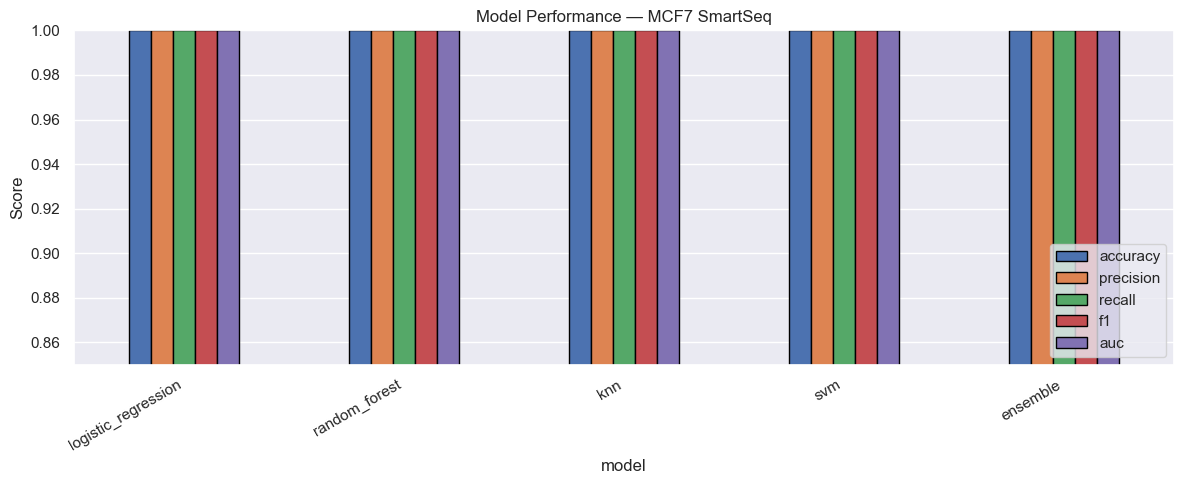

In [591]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
plot_df = scores_df[['model'] + metrics].set_index('model')

plot_df.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Model Performance — MCF7 SmartSeq')
plt.ylabel('Score')
plt.ylim(0.85, 1.0)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

<p style="font-size:15px; line-height:1.6;"> Overall, the models show exceptional performances across all evaluation metrics. 

**Confusion Matrices**

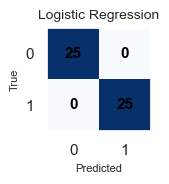

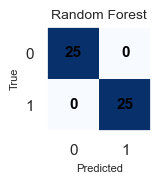

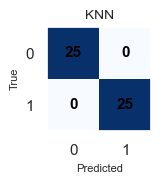

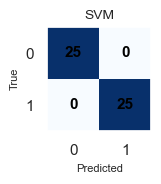

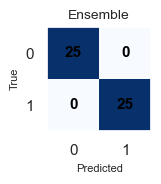

In [592]:
models = {
    "Logistic Regression": best_models['logistic_regression'][0],
    "Random Forest": best_models['random_forest'][0],
    "KNN": best_models['knn'][0],
    "SVM": best_models['svm'][0],
    "Ensemble": ensemble
}
for name, model in models.items():

    y_pred = model.predict(X_test)
    cm = confusion_matrix(Y_test, y_pred)

    fig, ax = plt.subplots(figsize=(2, 2))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.grid(False)

    for text in disp.text_.ravel():
        text.set_color("black")
        text.set_fontsize(11)
        text.set_fontweight("bold")

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)

    plt.tight_layout()
    plt.show()

<p style="font-size:15px; line-height:1.6;"> The confusion matrices further confirm the strong predictive performance of the models, with no false positives or false negatives. This perfect classification suggests that the selected genes are highly informative and that the two biological conditions are strongly separable in this dataset.

**ROC Plots**

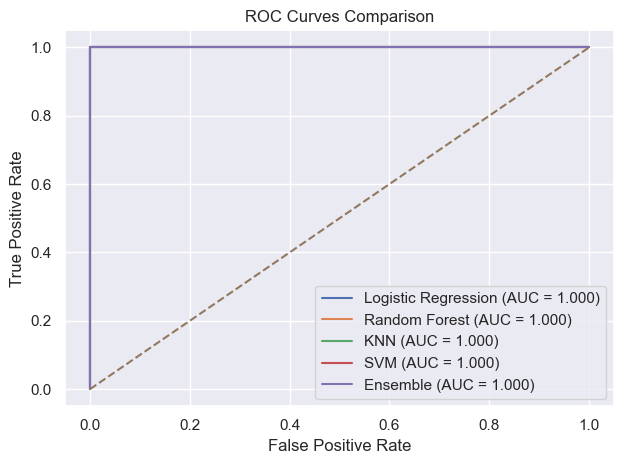

In [593]:
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()

plt.tight_layout()
plt.show()

<p style="font-size:15px; line-height:1.6;"> All curves overlap perfectly in the top-left corner of the graph and achieve an AUC value of 1, indicating perfect separation between the two conditions. 

#### **Best Model across cell lines and experiments** 

<p style="font-size:15px; line-height:1.6;"> To truly assess the predictive performance of our five models, we compare the performance of the models trained on the MCF7 SmartSeq dataset across all other cell lines and sequencing technologies. This is done to evaluate the generalization ability of the models beyond the datasets on which they were originally trained. </p>

In [594]:
hcc1806_SS = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt", delimiter="\ ", engine="python", index_col=0 )
hcc1806_DS = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/HCC1806_Drop_Filtered_Normalised_3000_Data_train.txt", delimiter="\ ", engine="python", index_col=0)
mcf07_DS = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/MCF7_Drop_Filtered_Normalised_3000_Data_train.txt", delimiter="\ ", engine="python", index_col=0)

Again, we prepare the datasets and create the target labels corresponding to the two conditions:

In [595]:
def split(dataset):
    dataset = dataset.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in dataset.columns})
    dataset = dataset.T
    dataset = dataset.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in dataset.columns})
    dataset['label'] = dataset.index.to_series().apply(lambda x: 0 if 'Norm' in x else 1)
    X = dataset.drop("label", axis = 1)
    Y = dataset["label"]
    
    return X, Y

<p style="font-size:15px; line-height:1.6;">We define a function that evaluates the best-performing trained model of each algorithm on the added datasets:</p>

In [596]:
def evaluate_on_dataset(best_models, dataset, dataset_name):
    X, Y = split(dataset)

    X = X.reindex(columns=X_train.columns, fill_value=0)
    results = []
    for name, (model, best_params) in best_models.items():
        scoress = evaluate_model(model, X, Y, name)
        scoress["dataset"] = dataset_name
        results.append(scoress)

    return pd.DataFrame(results)

In [597]:
trained_models = {
    "Logistic Regression": best_models['logistic_regression'][0],
    "Random Forest": best_models['random_forest'][0],
    "KNN": best_models['knn'][0],
    "SVM": best_models['svm'][0],
    "Ensemble": ensemble
}

**MCF7 DropSeq**

In [598]:
mcf07_DS_results = pd.concat([evaluate_on_dataset(best_models, mcf07_DS, "MCF7 DropSeq")], ignore_index=True)
mcf07_DS_results

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model,accuracy,precision,recall,f1,auc,dataset
0,logistic_regression,0.723990,0.656522,0.69398,0.674732,0.787698,MCF7 DropSeq
1,random_forest,0.412513,0.412513,1.00000,0.584084,0.500000,MCF7 DropSeq
2,knn,0.587487,0.000000,0.00000,0.000000,0.500000,MCF7 DropSeq
3,svm,0.587487,0.000000,0.00000,0.000000,0.699382,MCF7 DropSeq
4,ensemble,0.587487,0.000000,0.00000,0.000000,0.787688,MCF7 DropSeq


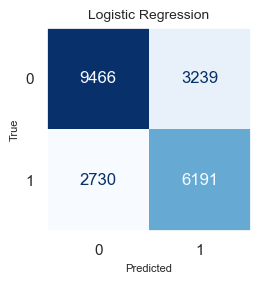

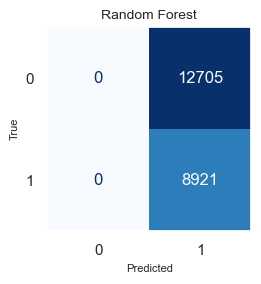

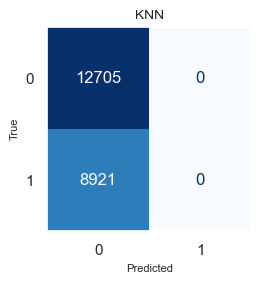

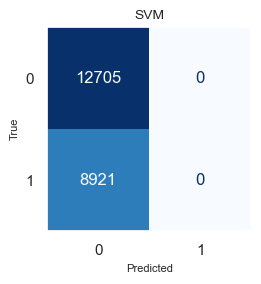

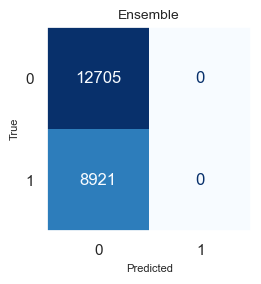

In [599]:
X, Y = split(mcf07_DS)
X = X.reindex(columns=X_train.columns, fill_value=0)

for name, model in trained_models.items():

    y_pred = model.predict(X)
    cm = confusion_matrix(Y, y_pred)

    fig, ax = plt.subplots(figsize=(3,3))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.grid(False)

    ax.set_title(f"{name}", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)

    plt.tight_layout()
    plt.show()

<p style="font-size:15px; line-height:1.6;"> Logistic Regression obtained the highest accuracy, F1-score and balanced classification metrics. Unlike the other models, which had the tendency to predict mainly one class as seen from the confusion matrices, Logistic Regression successfully identified both conditions. This suggests that linear decision boundaries generalized best across technologies for this dataset. </p>

<p style="font-size:15px; line-height:1.6;">The poorer performance of most models on this dataset is likely influenced by differences between sequencing technologies, as DropSeq generally produces sparser and noisier gene expression data compared to SmartSeq. </p>

**HCC1806 SmartSeq**

In [600]:
hcc1806_SS_results = pd.concat([evaluate_on_dataset(best_models, hcc1806_SS, "HCC1806 SmartSeq")], ignore_index=True)
hcc1806_SS_results

,model,accuracy,precision,recall,f1,auc,dataset
0,logistic_regression,0.868132,0.986667,0.762887,0.860465,0.954154,HCC1806 SmartSeq
1,random_forest,0.538462,0.535912,1.000000,0.697842,0.978229,HCC1806 SmartSeq
2,knn,0.489011,1.000000,0.041237,0.079208,0.583687,HCC1806 SmartSeq
3,svm,0.631868,0.767857,0.443299,0.562092,0.766768,HCC1806 SmartSeq
4,ensemble,0.758242,0.964912,0.567010,0.714286,0.935112,HCC1806 SmartSeq


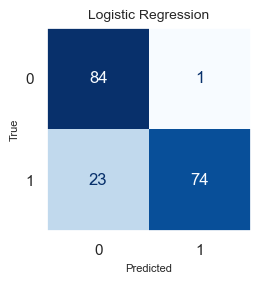

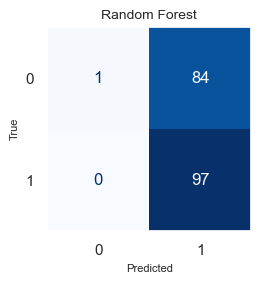

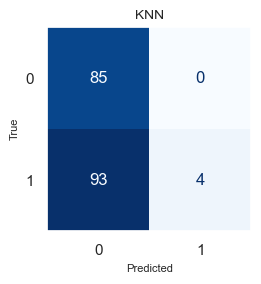

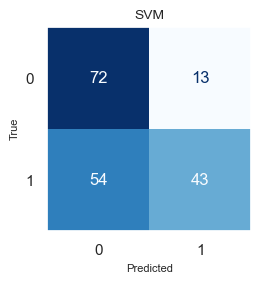

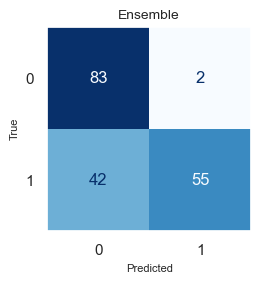

In [601]:
X, Y = split(hcc1806_SS)
X = X.reindex(columns=X_train.columns, fill_value=0)

for name, model in trained_models.items():

    y_pred = model.predict(X)
    cm = confusion_matrix(Y, y_pred)

    fig, ax = plt.subplots(figsize=(3,3))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.grid(False)

    ax.set_title(f"{name}", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)

    plt.tight_layout()
    plt.show()

<p style="font-size:15px; line-height:1.6;">In this case, Logistic Regression achieved the best overall performance, obtaining the highest accuracy and F1-score while maintaining a strong balance between precision and recall. 
Random Forest achieved a perfect recall, but at the cost of lower precision and overall accuracy.Surprisingly, the ensemble outperformed KNN and SVM. In contrast, the other models showed weaker generalization performance.  So, in this dataset, Logistic Regression is better able to capture its complexity. </p>

**HCC1806 DropSeq**

In [602]:
hcc1806_DS_results = pd.concat([evaluate_on_dataset(best_models, hcc1806_DS, "HCC1806 DropSeq")], ignore_index=True)
hcc1806_DS_results

/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model,accuracy,precision,recall,f1,auc,dataset
0,logistic_regression,0.621441,0.713975,0.626363,0.667305,0.665912,HCC1806 DropSeq
1,random_forest,0.606116,0.606116,1.000000,0.754760,0.500000,HCC1806 DropSeq
2,knn,0.393884,0.000000,0.000000,0.000000,0.500000,HCC1806 DropSeq
3,svm,0.393884,0.000000,0.000000,0.000000,0.640768,HCC1806 DropSeq
4,ensemble,0.393884,0.000000,0.000000,0.000000,0.665941,HCC1806 DropSeq


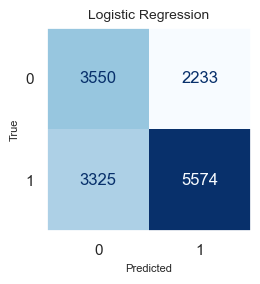

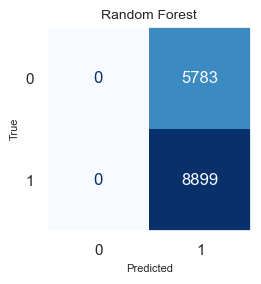

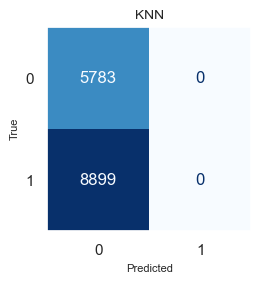

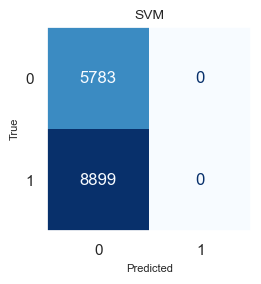

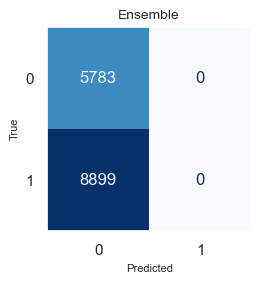

In [603]:
X, Y = split(hcc1806_DS)
X = X.reindex(columns=X_train.columns, fill_value=0)

for name, model in trained_models.items():

    y_pred = model.predict(X)
    cm = confusion_matrix(Y, y_pred)

    fig, ax = plt.subplots(figsize=(3,3))

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )

    ax.grid(False)

    ax.set_title(f"{name}", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)

    plt.tight_layout()
    plt.show()

<p style="font-size:15px; line-height:1.6;">In this final dataset, again Logistic Regression performed better, obtaining an F1-score of 0.62 approximately. In contrast, KNN, SVM, and the Ensemble model failed to predict any positive hypoxic samples, resulting in zero precision, recall, and F1-scores. Random Forest achieved perfect recall, meaning that all hypoxic samples were identified. However, the model classified all samples as hypoxic, including the normoxic ones. This indicates that the classifier was strongly biased and presented poor discrimination between the two conditions. The above is expected given the increased sparsity and noise of the DropSeq dataset.</p>

##### **Overall Analysis**

<p style="font-size:15px; line-height:1.6;">In general, this analysis revealed substantial differences in the generalization abilities of the tested models across different cell lines and technologies. </p>

<p style="font-size:15px; line-height:1.6;">Logistic Regression was the best-performing model across the external datasets. Unlike the other classifiers, Logistic Regression was able to correctly identify both conditions and, generally, demonstrated strong robustness and good generalization. </p>

<p style="font-size:15px; line-height:1.6;">Random Forest occasionally achieved perfect recall. However, the model classified nearly all cells as hypoxic, leading to a low precision. 

<p style="font-size:15px; line-height:1.6;">KNN and SVM, undoubtedly, performed exceptionally well on the original dataset. However, when evaluated on the other datasets, their performance dropped significantly. In most cases, the models struggled to distinguish between the two biological classes and generally were the weakest models of all. The ensemble didn't outperform the best individual models, but it achieved an intermediate performance.  </p>

<p style="font-size:15px; line-height:1.6;">So, the results suggest that Logistic Regression with [C: 0.001, penalty: l2, solver: liblinear] as hyperparameters was more balanced, robust, and reliable. These results indicate that the simpler linear models may generalize more effectively across the biological datasets.</p> 




##### **Feature Importance**

In [604]:
lr_model = best_models["logistic_regression"][0]
coef = lr_model.coef_[0]

genes = X_train.columns


importance_df = pd.DataFrame({
    "Gene": genes,
    "Importance": np.abs(coef)
})


importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

importance_df.head(10)


,Gene,Importance
0,MT-CO1,0.000570
1,MT-CYB,0.000480
2,MT-CO2,0.000435
3,PGK1,0.000361
4,XBP1,0.000306
5,CYP1B1,0.000287
6,ACTG1,0.000280
7,CTSD,0.000236
8,MT-CO3,0.000235
9,SCD,0.000227


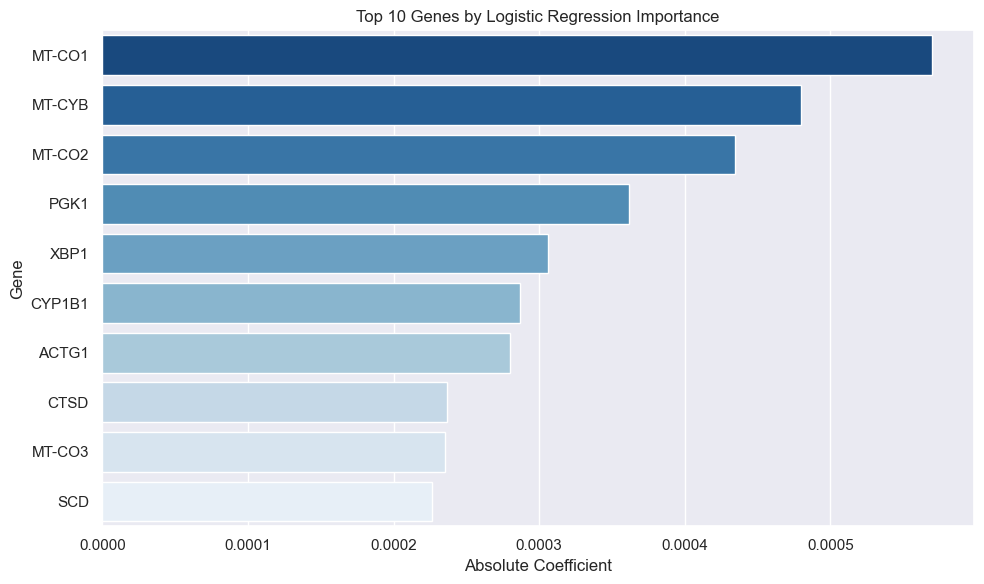

In [605]:
top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Gene",
    palette="Blues_r"
)

plt.title("Top 10 Genes by Logistic Regression Importance")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Gene")

plt.tight_layout()
plt.show()

<p style="font-size:15px; line-height:1.6;">The feature importance analysis highlights the genes that contributed the most to the predictions of the Logistic Regression model. Since the model was identified as the most robust and generalizable across different cell lines and sequencing technologies, the corresponding coefficients provide insight into the biological patterns associated with hypoxia and normoxia. Larger absolute coefficients indicate genes with stronger influence on the classification task.</p> 


<p style="font-size:15px; line-height:1.6;">Among the most important genes, several are known to play key roles in cellular metabolism and hypoxic responses. In particular, <b>MT-CO1</b>, <b>MT-CYB</b>, and <b>MT-CO2</b> are mitochondrial genes involved in the cellular respiration and energy metabolism. Their high importance suggests that hypoxia strongly affects how cells produce and use energy. Additionally, <b>PGK1</b> is a gene involved in glycolysis, a process that cells rely on more heavily under low oxygen conditions. The gene <b>XBP1</b> is involved in cellular stress responses pathways, which are often activated under hypoxic stress conditions.</p> 


<p style="font-size:15px; line-height:1.6;">Overall, the feature importance results are biologically consistent and further emphasize the ability of the Logistic Regression model to identify meaningful biological patterns within the gene expression data.</p>

<p style="font-size:15px; line-height:1.6;">The last step of this group's project is the pathway analysis of the most important genes identified by the best-performing classifier. This is presented in the HCC1806 SmartSeq supervised learning notebook, as this model demonstrated the strongest overall generalization performance across the external datasets.</p>

<p style="font-size:15px; line-height:1.6;"> To conclude this notebook, we generate predictions on previously unseen data.</p>

### **Predictions**

<p style="font-size:15px; line-height:1.6;">We proceed by testing our best-performing model, Logistic Regression, on unseen data. And saving its predictions.</p>

In [606]:
anonim = pd.read_csv("/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/MCF7_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt", delimiter="\ ",engine='python',index_col=0)
anonim = anonim.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in anonim.columns})
anonim = anonim.T
anonim = anonim.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in anonim.columns})
anonim.head()

,CYP1B1,CYP1B1-AS1,CYP1A1,NDRG1,DDIT4,PFKFB3,HK2,AREG,MYBL2,ADM,...,CD27-AS1,DNAI7,MAFG,LZTR1,BCO2,GRIK5,SLC25A27,DENND5A,CDK5R1,FAM13A-AS1
1,492,253,0,1157,6805,5447,2662,2448,0,58,...,0,0,193,0,0,0,0,285,0,1
2,7199,3245,7181,1857,20731,4374,5490,0,0,2150,...,0,0,187,0,0,0,0,55,0,0
3,12,11,1,5,147,301,9,647,1890,1,...,0,0,28,0,0,0,0,1,0,0
4,373,187,0,0,43,37,0,0,580,0,...,21,0,131,0,0,0,0,3,0,0
5,31,13,0,0,0,44,8,0,554,0,...,43,0,30,0,0,0,0,1,0,0


In [607]:
X_unseen = anonim[X_train.columns]
lr_model = best_models["logistic_regression"][0]

y_pred_unseen = lr_model.predict(X_unseen)
y_prob_unseen = lr_model.predict_proba(X_unseen)[:, 1]

predictions = pd.DataFrame({ "sample": X_unseen.index, "prediction": y_pred_unseen, "probability_hypoxia": y_prob_unseen})
predictions.to_csv('/Users/nikimaz/Documents/Bocconi Courses Year Two 2025-2026/AI LAB/predictions_MCF7SmartSeq.csv')
predictions


,sample,prediction,probability_hypoxia
0,1,1,1.000000e+00
1,2,1,1.000000e+00
2,3,0,5.055071e-05
3,4,0,6.148885e-05
4,5,0,1.481589e-07
...,...,...,...
58,59,1,9.999785e-01
59,60,1,1.000000e+00
60,61,1,1.000000e+00
61,62,0,7.263589e-06
